<div style="background:linear-gradient(to right, #4facfe, #00f2fe);
padding:15px;
border-radius:10px;
color:white;">

<h1>📊 Retail Sales Performance Analysis</h1>

<h3>🟢 Excel  
🔵 SQL  
🟣 Power BI  
🟠 Python  
🐼 Pandas  
🔢 NumPy  
📊 Matplotlib</h3>

</div>

# 🔥 Build `Connectivity` with MySQL

In [1]:
import mysql.connector

conn = mysql.connector.connect(

    host = 'localhost',
    user = 'root',
    password = '5689',
    database = 'SALES_ANALYSIS'
)

print("Connected Successfully")

Connected Successfully


## 🎯 Import Data From `MySQL` to `Pandas`

In [2]:
import pandas as pd

query = "select * from sales_data"

df = pd.read_sql(query, conn)

df.head()

C:\Users\ayush\AppData\Local\Temp\ipykernel_15432\3036835647.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0


<h2 style="color:green;">📊 Start Data Cleaning</h2>

### 🔹 `Check DataType of all Column`

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ORDRER_ID   50 non-null     int64  
 1   ORDER_DATE  48 non-null     object 
 2   PRODUCT     49 non-null     object 
 3   CATEGORY    50 non-null     object 
 4   REGION      46 non-null     object 
 5   QUANTITY    50 non-null     int64  
 6   UNIT_PRICE  48 non-null     float64
 7   SALES       48 non-null     float64
dtypes: float64(2), int64(2), object(4)
memory usage: 3.3+ KB


## 🔹convert `Date` Datatype `Object` to `datetime`

In [4]:
df['ORDER_DATE'] = pd.to_datetime(df['ORDER_DATE'], format = 'mixed')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ORDRER_ID   50 non-null     int64         
 1   ORDER_DATE  48 non-null     datetime64[ns]
 2   PRODUCT     49 non-null     object        
 3   CATEGORY    50 non-null     object        
 4   REGION      46 non-null     object        
 5   QUANTITY    50 non-null     int64         
 6   UNIT_PRICE  48 non-null     float64       
 7   SALES       48 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 3.3+ KB


### 🔹 `Check Duplicate Values`

In [6]:
df[['ORDER_DATE', 'PRODUCT', 'CATEGORY','REGION','QUANTITY','UNIT_PRICE','SALES']].duplicated().sum()

np.int64(4)

## .🔹 Remove `Duplicate` values & rows

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

###  🔹`Check Null Value`

In [9]:
 df.isnull().sum()

ORDRER_ID     0
ORDER_DATE    2
PRODUCT       1
CATEGORY      0
REGION        4
QUANTITY      0
UNIT_PRICE    2
SALES         2
dtype: int64

In [10]:
 df.isnull().sum().sum()

np.int64(11)

### 🔹 Concept of Handling Missing Values

Before using **`fillna()`** or **`dropna()`**, first check the dataset size using:

```python
df.shape
```

If the dataset contains **hundreds or thousands of rows**, then **11 missing values** are very small. In that case, **`dropna()`** can be used.

However, in this dataset the shape is **(50, 8)**, which means it contains **50 rows** and **8 columns**. Since the dataset is small, removing rows may result in the loss of valuable information.

Therefore, **`fillna()`** is a better choice for handling missing values in this dataset.

In [11]:
df.shape

(50, 8)

In [12]:
df.head(25)

,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0
5,1060,2025-03-02,Monitor,Electronics,None,1,12000.0,12000.0
6,1061,2025-03-03,Printer,Electronics,South,2,15000.0,30000.0
7,1062,2025-04-07,Mouse,Electronics,South,10,500.0,5000.0
8,1063,2025-03-05,Sofa,Furniture,West,1,25000.0,25000.0
9,1064,2025-03-06,Laptop,Electronics,North,1,NaN,NaN


### 🔹Handling Missing Date Values

Filled missing date values using **Mode** (the most frequent value), as it is suitable for **categorical data and date columns**.

In [13]:
df['ORDER_DATE'] = df['ORDER_DATE'].fillna(df['ORDER_DATE'].mode()[0])

In [14]:
df.isnull().sum().sum()

np.int64(9)

In [15]:
df.head(25)

,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0
5,1060,2025-03-02,Monitor,Electronics,None,1,12000.0,12000.0
6,1061,2025-03-03,Printer,Electronics,South,2,15000.0,30000.0
7,1062,2025-04-07,Mouse,Electronics,South,10,500.0,5000.0
8,1063,2025-03-05,Sofa,Furniture,West,1,25000.0,25000.0
9,1064,2025-03-06,Laptop,Electronics,North,1,NaN,NaN


### 🔹Handling Missing Product Values

Filled missing values in the **PRODUCT** column using **Mode** (the most frequent product).

Mode represents the **most frequently occurring value** in the dataset and is commonly used for **categorical columns** such as Product, Region, Category, and City.

In [16]:
df['PRODUCT'] = df['PRODUCT'].fillna(df['PRODUCT'].mode()[0])

df.head(25)

,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0
5,1060,2025-03-02,Monitor,Electronics,None,1,12000.0,12000.0
6,1061,2025-03-03,Printer,Electronics,South,2,15000.0,30000.0
7,1062,2025-04-07,Mouse,Electronics,South,10,500.0,5000.0
8,1063,2025-03-05,Sofa,Furniture,West,1,25000.0,25000.0
9,1064,2025-03-06,Laptop,Electronics,North,1,NaN,NaN


In [17]:
df.isnull().sum().sum()

np.int64(8)

### 🔹 Handling Missing REGION Values

Filled missing values in the **REGION** column using **Mode** (the most frequent product).

Mode represents the **most frequently occurring value** in the dataset and is commonly used for **categorical columns** such as Product, Region, Category, and City.

In [18]:
df['REGION'] = df['REGION'].fillna(df['REGION'].mode()[0])
df.head(25)

,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0
5,1060,2025-03-02,Monitor,Electronics,South,1,12000.0,12000.0
6,1061,2025-03-03,Printer,Electronics,South,2,15000.0,30000.0
7,1062,2025-04-07,Mouse,Electronics,South,10,500.0,5000.0
8,1063,2025-03-05,Sofa,Furniture,West,1,25000.0,25000.0
9,1064,2025-03-06,Laptop,Electronics,North,1,NaN,NaN


In [19]:
df.isnull().sum().sum()

np.int64(4)

### 🔹 Handling Missing Unit Price Values

Filled missing values in the **UNIT_PRICE** column using **Median**.

Median is suitable for numerical data because it is less affected by extreme values (outliers) and provides a better representation of the central tendency of the data.

In [20]:
df['UNIT_PRICE'] = df['UNIT_PRICE'].fillna(df['UNIT_PRICE'].median())

df.head(25)

,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0
5,1060,2025-03-02,Monitor,Electronics,South,1,12000.0,12000.0
6,1061,2025-03-03,Printer,Electronics,South,2,15000.0,30000.0
7,1062,2025-04-07,Mouse,Electronics,South,10,500.0,5000.0
8,1063,2025-03-05,Sofa,Furniture,West,1,25000.0,25000.0
9,1064,2025-03-06,Laptop,Electronics,North,1,9500.0,NaN


In [21]:
df['SALES'] = df['SALES'].fillna(df['UNIT_PRICE'] * df['QUANTITY'])
df.head(25)

,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0
5,1060,2025-03-02,Monitor,Electronics,South,1,12000.0,12000.0
6,1061,2025-03-03,Printer,Electronics,South,2,15000.0,30000.0
7,1062,2025-04-07,Mouse,Electronics,South,10,500.0,5000.0
8,1063,2025-03-05,Sofa,Furniture,West,1,25000.0,25000.0
9,1064,2025-03-06,Laptop,Electronics,North,1,9500.0,9500.0


In [22]:
df.isnull().sum().sum()

np.int64(0)

## 📫Dataset Information

In [23]:
df.shape

(50, 8)

In [24]:
df.columns

Index(['ORDRER_ID', 'ORDER_DATE', 'PRODUCT', 'CATEGORY', 'REGION', 'QUANTITY',
       'UNIT_PRICE', 'SALES'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ORDRER_ID   50 non-null     int64         
 1   ORDER_DATE  50 non-null     datetime64[ns]
 2   PRODUCT     50 non-null     object        
 3   CATEGORY    50 non-null     object        
 4   REGION      50 non-null     object        
 5   QUANTITY    50 non-null     int64         
 6   UNIT_PRICE  50 non-null     float64       
 7   SALES       50 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 3.3+ KB


In [26]:
df.describe()

,ORDRER_ID,ORDER_DATE,QUANTITY,UNIT_PRICE,SALES
count,50.00000,50,50.000000,50.000000,50.000000
mean,1079.50000,2025-03-22 20:38:24,4.320000,15570.000000,27830.000000
min,1055.00000,2025-02-25 00:00:00,1.000000,500.000000,4000.000000
25%,1067.25000,2025-03-12 06:00:00,1.250000,2125.000000,9625.000000
50%,1079.50000,2025-03-24 00:00:00,2.000000,9500.000000,17500.000000
75%,1091.75000,2025-04-03 18:00:00,5.000000,18000.000000,34500.000000
max,1104.00000,2025-04-14 00:00:00,25.000000,55000.000000,106000.000000
std,14.57738,NaN,4.979304,17783.565562,27612.406632


## 🎯 Create New Features

### 🔹 Add Year Columns

In [27]:
df['YEAR'] = df['ORDER_DATE'].dt.year

### 🔹 Add Month Columns

In [28]:
df['MONTH'] = df['ORDER_DATE'].dt.month_name()

### 🔹 Add Day Columns

In [29]:
df['DAY'] = df['ORDER_DATE'].dt.day_name()

In [30]:
df.head()

,ORDRER_ID,ORDER_DATE,PRODUCT,CATEGORY,REGION,QUANTITY,UNIT_PRICE,SALES,YEAR,MONTH,DAY
0,1055,2025-02-25,Laptop,Electronics,North,2,52000.0,104000.0,2025,February,Tuesday
1,1056,2025-03-24,Laptop,Electronics,South,1,55000.0,55000.0,2025,March,Monday
2,1057,2025-02-27,Keyboard,Electronics,East,5,1500.0,7500.0,2025,February,Thursday
3,1058,2025-02-28,Chair,Furniture,West,3,4000.0,12000.0,2025,February,Friday
4,1059,2025-03-01,Desk,Furniture,North,2,7000.0,14000.0,2025,March,Saturday


<div style="color:white;background-color:green;padding:10px;border-radius:5px;">
✅ Data Cleaning Completed Successfully
</div>

<h2 style="color:red;">🐍 Start Python Analysis</h2>

## 🚀 Product Analysis

### 🔹 product generated the highest sales

In [31]:
df.groupby('PRODUCT')['SALES'].sum()

PRODUCT
Chair        88000.0
Desk         42000.0
Keyboard     45000.0
Laptop      659500.0
Monitor     120000.0
Mouse        55000.0
Printer     109000.0
Sofa         75000.0
Tablet      198000.0
Name: SALES, dtype: float64

### 🔹 product generated the lowest sales

In [32]:
df.groupby('PRODUCT')['SALES'].sum().sort_values(ascending = True)

PRODUCT
Desk         42000.0
Keyboard     45000.0
Mouse        55000.0
Sofa         75000.0
Chair        88000.0
Printer     109000.0
Monitor     120000.0
Tablet      198000.0
Laptop      659500.0
Name: SALES, dtype: float64

### 🔹 products are most frequently sold

In [33]:
df['PRODUCT'].value_counts()

PRODUCT
Laptop      10
Mouse        8
Chair        6
Keyboard     5
Monitor      5
Printer      5
Desk         4
Tablet       4
Sofa         3
Name: count, dtype: int64

### 🔹 percentage of total sales comes from each product

In [34]:
(df.groupby('PRODUCT')['SALES'].sum()/df['SALES'].sum()* 100).round(2)

PRODUCT
Chair        6.32
Desk         3.02
Keyboard     3.23
Laptop      47.39
Monitor      8.62
Mouse        3.95
Printer      7.83
Sofa         5.39
Tablet      14.23
Name: SALES, dtype: float64

## 🚀 Category Analysis

### 🔹Category performs best

In [35]:
df.groupby('CATEGORY')['SALES'].sum()

CATEGORY
Electronics    1165500.0
Furniture       226000.0
Name: SALES, dtype: float64

### 🔹Category performs worst

In [36]:
df.groupby('CATEGORY')['SALES'].sum().sort_values(ascending=True)

CATEGORY
Furniture       226000.0
Electronics    1165500.0
Name: SALES, dtype: float64

### 🔹Category-wise sales contribution.

In [37]:
(df.groupby('CATEGORY')['SALES'].sum()/df['SALES'].sum() * 100).round(2)

CATEGORY
Electronics    83.76
Furniture      16.24
Name: SALES, dtype: float64

## 🚀 Region Analysis

### 🔹 Region generates the highest revenue

In [38]:
df.groupby('REGION')['SALES'].sum()

REGION
East     251000.0
North    491000.0
South    430000.0
West     219500.0
Name: SALES, dtype: float64

### 🔹 Region generates the highest revenue

In [39]:
df.groupby('REGION')['SALES'].sum().sort_values(ascending=True)

REGION
West     219500.0
East     251000.0
South    430000.0
North    491000.0
Name: SALES, dtype: float64

### 🔹 Region-wise sales distribution.

In [40]:
(df.groupby('REGION')['SALES'].sum()/df['SALES'].sum() * 100).round(2)

REGION
East     18.04
North    35.29
South    30.90
West     15.77
Name: SALES, dtype: float64

## 🚀 Time-Based Analysis

### 🔹month has the highest sales

In [41]:
df.groupby('MONTH')['SALES'].sum()

MONTH
April       456500.0
February    123500.0
March       811500.0
Name: SALES, dtype: float64

### 🔹 month has the lowest sales

In [42]:
df.groupby('MONTH')['SALES'].sum().sort_values(ascending= True)

MONTH
February    123500.0
April       456500.0
March       811500.0
Name: SALES, dtype: float64

### 🔹sales increasing or decreasing over time

In [43]:
df.groupby('MONTH')['SALES'].sum()

MONTH
April       456500.0
February    123500.0
March       811500.0
Name: SALES, dtype: float64

## 🚀 Quantity Analysis

### 🔹 product sells the highest quantity

In [44]:
df.groupby('PRODUCT')['QUANTITY'].sum()

PRODUCT
Chair        22
Desk          6
Keyboard     30
Laptop       16
Monitor      10
Mouse       110
Printer       8
Sofa          3
Tablet       11
Name: QUANTITY, dtype: int64

### 🔹 product sells the lowest quantity

In [45]:
df.groupby('PRODUCT')['QUANTITY'].sum().sort_values(ascending = True)

PRODUCT
Sofa          3
Desk          6
Printer       8
Monitor      10
Tablet       11
Laptop       16
Chair        22
Keyboard     30
Mouse       110
Name: QUANTITY, dtype: int64

### 🔹 Average quantity sold per order

In [46]:
df['QUANTITY'].mean()

np.float64(4.32)

## 🚀 Sales Analysis

### 🔹Total sales.

In [47]:
df['SALES'].sum()

np.float64(1391500.0)

### 🔹Average sales per order

In [48]:
df['SALES'].mean()

np.float64(27830.0)

### 🔹Highest single sale.

In [49]:
df['SALES'].max()

106000.0

### 🔹Lowest single sale.

In [50]:
df['SALES'].min()

4000.0

<h2 style="color:orange;">📈 Data Visualization</h2>

In [51]:
import matplotlib.pyplot as plt

<b> 🔹Product generated the highest sales<br>
</b>

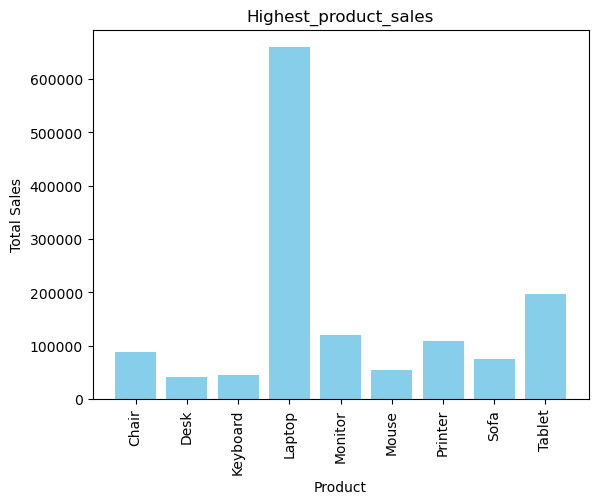

In [52]:
Heighest_product_sales = df.groupby('PRODUCT')['SALES'].sum()

plt.bar(Heighest_product_sales.index, Heighest_product_sales.values, color= 'skyblue')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Highest_product_sales')
plt.xticks(rotation=90)
plt.show()

### 🔹Product generated the lowest sales

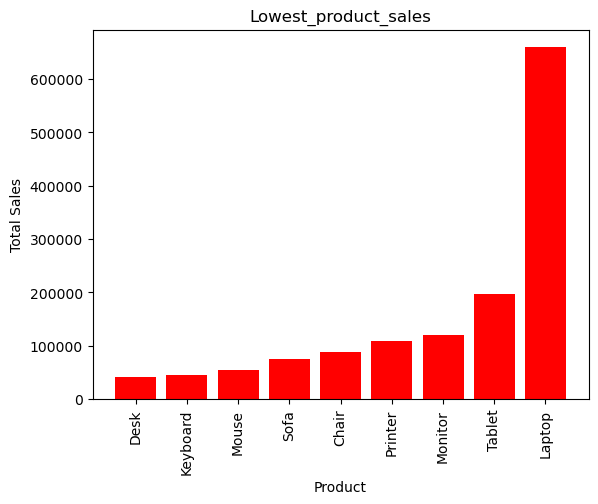

In [53]:
Lowest_product_sales= df.groupby('PRODUCT')['SALES'].sum().sort_values(ascending = True)

plt.bar(Lowest_product_sales.index, Lowest_product_sales.values, color ='red')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Lowest_product_sales')
plt.xticks(rotation=90)
plt.show()

### 🔹percentage of sales comes from each category

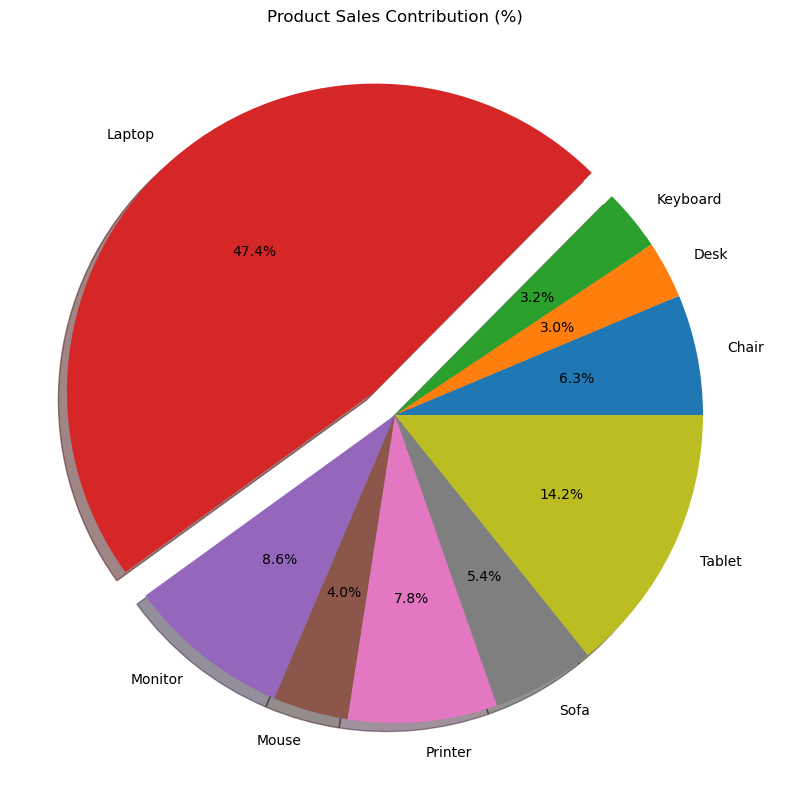

In [54]:
Sales_Per = (df.groupby('PRODUCT')['SALES'].sum()/df['SALES'].sum()*100).round(2)

plt.figure(figsize=(10,10))

explode = [0.1 if i == 'Laptop' else 0 for i in Sales_Per.index]

plt.pie(
    Sales_Per,
    labels=Sales_Per.index,
    autopct='%1.1f%%',
    explode=explode,
    shadow=True
)

plt.title('Product Sales Contribution (%)')
plt.show()

### 🔹 category contributes the most revenue

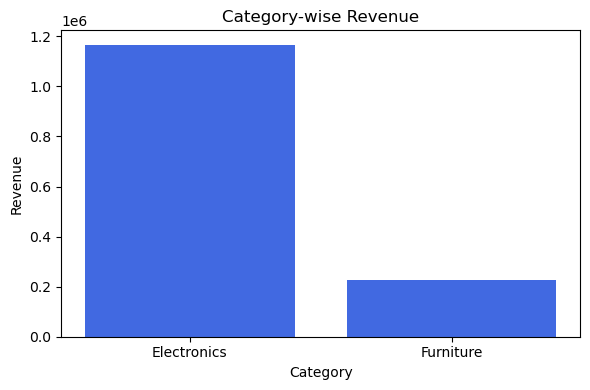

In [55]:
most_revenue = df.groupby('CATEGORY')['SALES'].sum()

plt.figure(figsize=(6,4))
plt.bar(most_revenue.index, most_revenue.values, color='royalblue' )
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Category-wise Revenue')
plt.tight_layout()
plt.show()

### 🔹sales increasing or decreasing over time

Text(0.5, 1.0, 'Monthly Sales Trend')

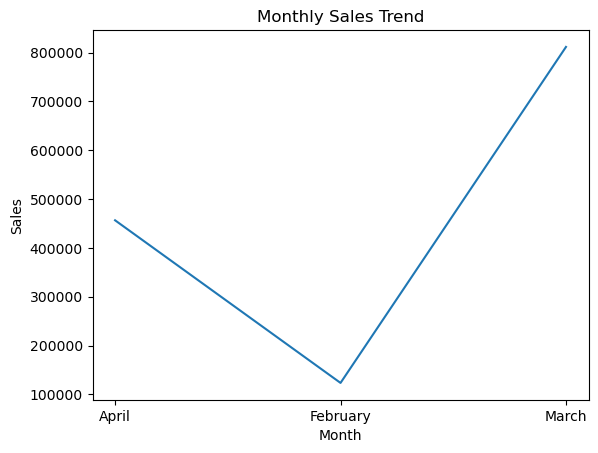

In [56]:
sales_over_time = df.groupby('MONTH')['SALES'].sum()

plt.plot(sales_over_time.index, sales_over_time.values)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Trend')

### 🔹sales values distributed

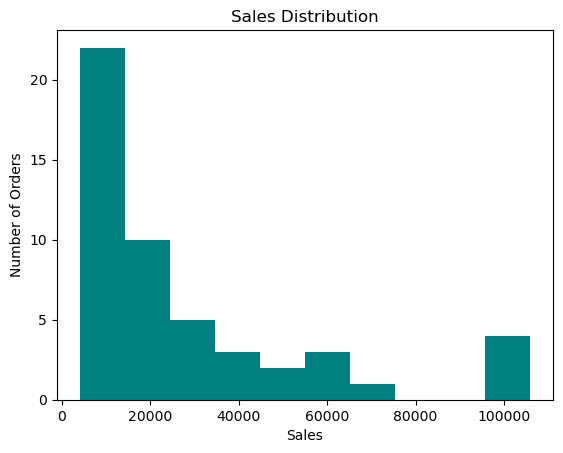

In [57]:
plt.hist(df['SALES'], color='teal')

plt.xlabel('Sales')
plt.ylabel('Number of Orders')
plt.title('Sales Distribution')
plt.show()